In [142]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Scenario:
- Healthcare nexus under flood hazard
	- PowerGrid, HospitalDiesel, HospitalPowerPanel
	- WaterPlant, HospitalWaterTank
	- FiberBackbone, CellTower, HospitalCommHub
	- Bridge, MainRoad, HospitalAccessRoad
	- HospitalFacility

- Time steps t = 0, 1, 2 (for example, days)
	- t0: pre flood (grid working)
	- t1: peak flood (grid, fiber, bridge lost, hospital moves to diesel)
	- t2: prolonged disruption (diesel fuel runs out, autonomy reached)

# Define nodes

In [156]:
nodes = [
    "PowerGrid",            # 0
    "HospitalDiesel",       # 1
    "HospitalPowerPanel",   # 2

    "WaterPlant",           # 3
    "HospitalWaterTank",    # 4

    "FiberBackbone",        # 5
    "CellTower",            # 6
    "HospitalCommHub",      # 7

    "Bridge",               # 8
    "MainRoad",             # 9
    "HospitalAccessRoad",   # 10

    "HospitalFacility"      # 11
]

idx = {name: i for i, name in enumerate(nodes)}
print(idx)
print(len(nodes))

{'PowerGrid': 0, 'HospitalDiesel': 1, 'HospitalPowerPanel': 2, 'WaterPlant': 3, 'HospitalWaterTank': 4, 'FiberBackbone': 5, 'CellTower': 6, 'HospitalCommHub': 7, 'Bridge': 8, 'MainRoad': 9, 'HospitalAccessRoad': 10, 'HospitalFacility': 11}
12


# Hazard intensity and flood fragility

## Hazard intensity (using flood depth as an example)

**Equation (1) - Hazard intensity**

We take flood depth in meters at each node as hazard intensity:

$$ d_i = \text{flood depth at node } i $$

In [151]:
# Peak flood depth (m) at each node, hypothetical
depth_peak = np.array([
    0.2,  # PowerGrid
    0.3,  # HospitalDiesel
    0.4,  # HospitalPowerPanel

    0.2,  # WaterPlant
    0.4,  # HospitalWaterTank

    0.4,  # FiberBackbone
    0.3,  # CellTower
    0.1,  # HospitalCommHub

    0.2,  # Bridge
    0.1,  # MainRoad
    0.3,  # HospitalAccessRoad

    0.2   # HospitalFacility
])

## Node types and type-specific fragility curves

Each node has a type that determines its fragility curve.

In [150]:
node_type = {
    "PowerGrid": "substation",
    "HospitalDiesel": "generator",
    "HospitalPowerPanel": "electrical_panel",

    "WaterPlant": "water_treatment",
    "HospitalWaterTank": "water_tank",

    "FiberBackbone": "comm_backbone",
    "CellTower": "cell_tower",
    "HospitalCommHub": "comm_hub",

    "Bridge": "bridge",
    "MainRoad": "road",
    "HospitalAccessRoad": "road",

    "HospitalFacility": "hospital"
}

**Equation (2) - Flood fragility curve**

For each type we use a logistic curve:

$$P_{h,i} = f_{\text{type}(i)}(d_i) = \frac{1}{1 + \exp[-k_{\text{type}} (d_i - d_{0,\text{type}})]}$$

$k$ and $d0$ depend on the component type (only illustrative here).

In [152]:
# Fragility curves per type (toy parameters)
def fragility_substation(d):
    return 1.0 / (1.0 + np.exp(-6.0 * (d - 0.4)))

def fragility_generator(d):
    return 1.0 / (1.0 + np.exp(-5.0 * (d - 0.8)))

def fragility_electrical_panel(d):
    return 1.0 / (1.0 + np.exp(-7.0 * (d - 0.3)))

def fragility_water_treatment(d):
    return 1.0 / (1.0 + np.exp(-4.0 * (d - 1.5)))

def fragility_water_tank(d):
    return 1.0 / (1.0 + np.exp(-3.0 * (d - 2.0)))

def fragility_comm_backbone(d):
    return 1.0 / (1.0 + np.exp(-5.0 * (d - 0.7)))

def fragility_cell_tower(d):
    return 1.0 / (1.0 + np.exp(-4.0 * (d - 0.9)))

def fragility_comm_hub(d):
    return 1.0 / (1.0 + np.exp(-5.0 * (d - 0.5)))

def fragility_road(d):
    return 1.0 / (1.0 + np.exp(-5.0 * (d - 0.7)))

def fragility_bridge(d):
    return 1.0 / (1.0 + np.exp(-4.0 * (d - 1.0)))

def fragility_hospital(d):
    return 1.0 / (1.0 + np.exp(-5.0 * (d - 1.2)))


# Map type names to fragility functions
fragility_map = {
    "substation": fragility_substation,
    "generator": fragility_generator,
    "electrical_panel": fragility_electrical_panel,

    "water_treatment": fragility_water_treatment,
    "water_tank": fragility_water_tank,

    "comm_backbone": fragility_comm_backbone,
    "cell_tower": fragility_cell_tower,
    "comm_hub": fragility_comm_hub,

    "bridge": fragility_bridge,
    "road": fragility_road,

    "hospital": fragility_hospital
}

Compute hazard driven failure per node

In [153]:
# Hazard driven failure probability P_h,i for each node
P_hazard = np.zeros(n)
for i, name in enumerate(nodes):
    tname = node_type[name]
    print(tname)
    P_hazard[i] = fragility_map[tname](depth[i])

print(P_hazard)

substation


KeyError: 0

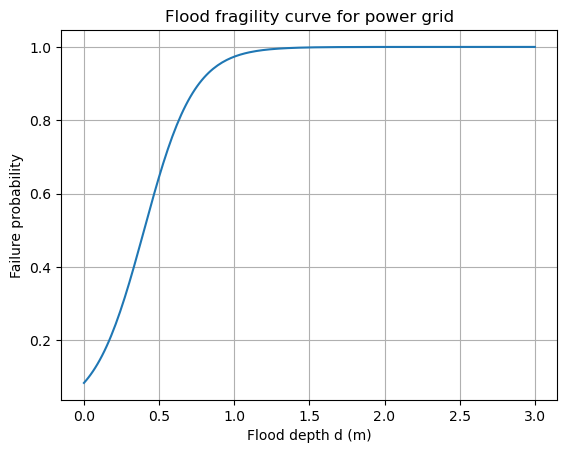

In [ ]:
# Create a range of flood depths (0 to 3 meters, for example)
d_values = np.linspace(0.0, 3.0, 200)   # 200 points between 0 and 3 m
P_fail = fragility_substation(d_values)

# Plot the curve
plt.figure()
plt.plot(d_values, P_fail)
plt.xlabel("Flood depth d (m)")
plt.ylabel("Failure probability")
plt.title("Flood fragility curve for power grid")
plt.grid(True)
plt.show()

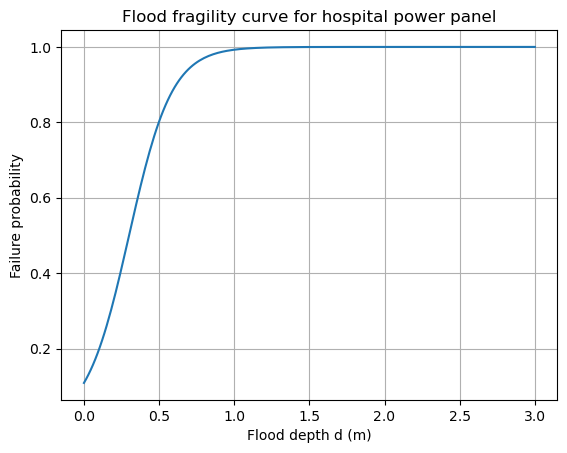

In [ ]:
# Create a range of flood depths (0 to 3 meters, for example)
d_values = np.linspace(0.0, 3.0, 200)   # 200 points between 0 and 3 m
P_fail = fragility_electrical_panel(d_values)

# Plot the curve
plt.figure()
plt.plot(d_values, P_fail)
plt.xlabel("Flood depth d (m)")
plt.ylabel("Failure probability")
plt.title("Flood fragility curve for hospital power panel")
plt.grid(True)
plt.show()

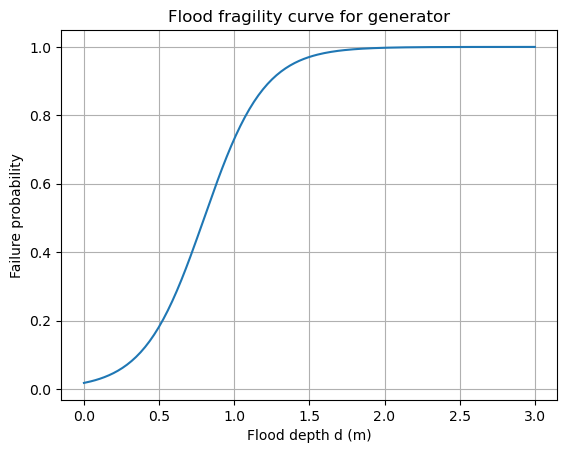

In [ ]:
# Create a range of flood depths (0 to 3 meters, for example)
d_values = np.linspace(0.0, 3.0, 200)   # 200 points between 0 and 3 m
P_fail = fragility_generator(d_values)

# Plot the curve
plt.figure()
plt.plot(d_values, P_fail)
plt.xlabel("Flood depth d (m)")
plt.ylabel("Failure probability")
plt.title("Flood fragility curve for generator")
plt.grid(True)
plt.show()

# Routine failure from daily records (depends on data availability)

add routine failure probability per time step.

**Equation (3) - routine failure**

$$P_{r,i} = \text{baseline failure probability per time step}$$

In [ ]:
# Routine failure per time step (synthetic)
P_routine_dict = {
    "PowerGrid": 0.005,
    "HospitalDiesel": 0.010,
    "HospitalPowerPanel": 0.002,

    "WaterPlant": 0.004,
    "HospitalWaterTank": 0.001,

    "FiberBackbone": 0.005,
    "CellTower": 0.004,
    "HospitalCommHub": 0.001,

    "Bridge": 0.003,
    "MainRoad": 0.002,
    "HospitalAccessRoad": 0.002,

    "HospitalFacility": 0.001
}

P_routine = np.array([P_routine_dict[name] for name in nodes])

# Self failure (failure during hazards combined with routine failure)

**Equation (4) - combined self failure**

Self failure includes hazard and routine causes. Assuming independence:

$$P_{sf,i} = 1 - (1 - P_{h,i})(1 - P_{r,i})$$

In [157]:
def combined_self_failure(P_hazard, P_routine):
    return 1.0 - (1.0 - P_hazard) * (1.0 - P_routine)

P_sf = combined_self_failure(P_hazard, P_routine)

print("Self failure probabilities (flood + routine):")
for name, d, ph, pr, psf in zip(nodes, depth, P_hazard, P_routine, P_sf):
    print(f"{name:20s} depth={d:4.1f}m  P_h={ph:.3f}  P_r={pr:.3f}  P_sf={psf:.3f}")

Self failure probabilities (flood + routine):


ValueError: Unknown format code 'f' for object of type 'str'

In [ ]:
T = 5
time_steps = list(range(T))

# Flood factor at each time step (0 to 1)
flood_factor = np.array([0.0, 0.5, 1.0, 0.5, 0.1])

In [154]:
def empty_adj(n):
    return np.zeros((n, n), dtype=int)

# A_grid: normal mode, grid feeds panel
A_grid = empty_adj(n)

# Power
A_grid[idx["HospitalPowerPanel"], idx["PowerGrid"]] = 1
A_grid[idx["HospitalFacility"], idx["HospitalPowerPanel"]] = 1

# Water
A_grid[idx["HospitalWaterTank"], idx["WaterPlant"]] = 1
A_grid[idx["HospitalFacility"], idx["HospitalWaterTank"]] = 1

# Communication
A_grid[idx["HospitalCommHub"], idx["FiberBackbone"]] = 1
A_grid[idx["HospitalCommHub"], idx["CellTower"]] = 1
A_grid[idx["HospitalFacility"], idx["HospitalCommHub"]] = 1

# Transport
A_grid[idx["MainRoad"], idx["Bridge"]] = 1
A_grid[idx["HospitalAccessRoad"], idx["MainRoad"]] = 1
A_grid[idx["HospitalFacility"], idx["HospitalAccessRoad"]] = 1

# A_diesel: emergency mode, diesel feeds panel instead of grid
A_diesel = empty_adj(n)

# Power
A_diesel[idx["HospitalPowerPanel"], idx["HospitalDiesel"]] = 1
A_diesel[idx["HospitalFacility"], idx["HospitalPowerPanel"]] = 1

# Water (same as grid mode)
A_diesel[idx["HospitalWaterTank"], idx["WaterPlant"]] = 1
A_diesel[idx["HospitalFacility"], idx["HospitalWaterTank"]] = 1

# Communication: maybe fiber is down, rely on cell tower only
A_diesel[idx["HospitalCommHub"], idx["CellTower"]] = 1
A_diesel[idx["HospitalFacility"], idx["HospitalCommHub"]] = 1

# Transport: assume bridge is unusable, but MainRoad and AccessRoad still connected locally
A_diesel[idx["HospitalAccessRoad"], idx["MainRoad"]] = 1
A_diesel[idx["HospitalFacility"], idx["HospitalAccessRoad"]] = 1

# A_nosupply: no external power for panel, but dependencies remain from panel to hospital
A_nosupply = empty_adj(n)

A_nosupply[idx["HospitalFacility"], idx["HospitalPowerPanel"]] = 1
A_nosupply[idx["HospitalFacility"], idx["HospitalWaterTank"]] = 1
A_nosupply[idx["HospitalFacility"], idx["HospitalCommHub"]] = 1
A_nosupply[idx["HospitalFacility"], idx["HospitalAccessRoad"]] = 1

IndexError: index 11 is out of bounds for axis 0 with size 3

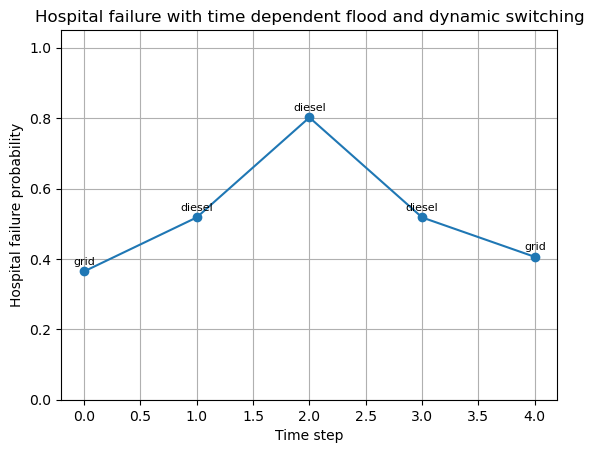

In [ ]:
plt.figure()
plt.plot(time_steps, hospital_failure, marker="o")
for t, m in zip(time_steps, active_mode):
    plt.text(t, hospital_failure[t] + 0.02, m, ha="center", fontsize=8)
plt.xlabel("Time step")
plt.ylabel("Hospital failure probability")
plt.title("Hospital failure with time dependent flood and dynamic switching")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()


=== Dynamic switching with temporal cascading ===

Time t = 0
Node                 depth_t   P_hazard_t   P_sf_t   F_t (cum)
PowerGrid             0.00m       0.083      0.088      0.000
HospitalDiesel        0.00m       0.018      0.028      0.000
HospitalPowerPanel    0.00m       0.109      0.111      0.000
WaterPlant            0.00m       0.002      0.006      0.000
HospitalWaterTank     0.00m       0.002      0.003      0.000
FiberBackbone         0.00m       0.029      0.034      0.000
CellTower             0.00m       0.027      0.030      0.000
HospitalCommHub       0.00m       0.076      0.077      0.000
Bridge                0.00m       0.018      0.021      0.000
MainRoad              0.00m       0.029      0.031      0.000
HospitalAccessRoad    0.00m       0.029      0.031      0.000
HospitalFacility      0.00m       0.002      0.003      0.000
Selected mode: grid
Hospital cumulative failure probability: 0.003
Cascading driver q_cf for this mode (first few nodes):
  PowerG

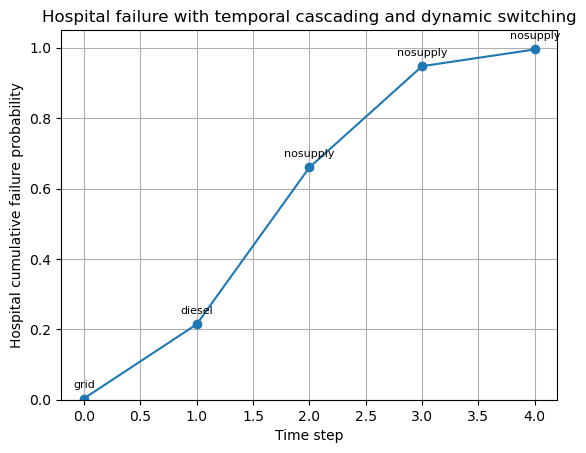

In [158]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ===============================
# 1. Nodes and indices
# ===============================

nodes = [
    "PowerGrid",            # 0
    "HospitalDiesel",       # 1
    "HospitalPowerPanel",   # 2

    "WaterPlant",           # 3
    "HospitalWaterTank",    # 4

    "FiberBackbone",        # 5
    "CellTower",            # 6
    "HospitalCommHub",      # 7

    "Bridge",               # 8
    "MainRoad",             # 9
    "HospitalAccessRoad",   # 10

    "HospitalFacility"      # 11
]

idx = {name: i for i, name in enumerate(nodes)}
n = len(nodes)

# ===============================
# 2. Node types for fragility
# ===============================

node_type = {
    "PowerGrid": "substation",
    "HospitalDiesel": "generator",
    "HospitalPowerPanel": "electrical_panel",

    "WaterPlant": "water_treatment",
    "HospitalWaterTank": "water_tank",

    "FiberBackbone": "comm_backbone",
    "CellTower": "cell_tower",
    "HospitalCommHub": "comm_hub",

    "Bridge": "bridge",
    "MainRoad": "road",
    "HospitalAccessRoad": "road",

    "HospitalFacility": "hospital"
}

# ===============================
# 3. Type specific flood fragility
# ===============================

def fragility_substation(d):
    return 1.0 / (1.0 + np.exp(-6.0 * (d - 0.4)))

def fragility_generator(d):
    return 1.0 / (1.0 + np.exp(-5.0 * (d - 0.8)))

def fragility_electrical_panel(d):
    return 1.0 / (1.0 + np.exp(-7.0 * (d - 0.3)))

def fragility_water_treatment(d):
    return 1.0 / (1.0 + np.exp(-4.0 * (d - 1.5)))

def fragility_water_tank(d):
    return 1.0 / (1.0 + np.exp(-3.0 * (d - 2.0)))

def fragility_comm_backbone(d):
    return 1.0 / (1.0 + np.exp(-5.0 * (d - 0.7)))

def fragility_cell_tower(d):
    return 1.0 / (1.0 + np.exp(-4.0 * (d - 0.9)))

def fragility_comm_hub(d):
    return 1.0 / (1.0 + np.exp(-5.0 * (d - 0.5)))

def fragility_road(d):
    return 1.0 / (1.0 + np.exp(-5.0 * (d - 0.7)))

def fragility_bridge(d):
    return 1.0 / (1.0 + np.exp(-4.0 * (d - 1.0)))

def fragility_hospital(d):
    return 1.0 / (1.0 + np.exp(-5.0 * (d - 1.2)))


fragility_map = {
    "substation": fragility_substation,
    "generator": fragility_generator,
    "electrical_panel": fragility_electrical_panel,

    "water_treatment": fragility_water_treatment,
    "water_tank": fragility_water_tank,

    "comm_backbone": fragility_comm_backbone,
    "cell_tower": fragility_cell_tower,
    "comm_hub": fragility_comm_hub,

    "bridge": fragility_bridge,
    "road": fragility_road,

    "hospital": fragility_hospital
}

# ===============================
# 4. Peak flood depth and time pattern
# ===============================

# Peak flood depth at each node (m) - synthetic
depth_peak = np.array([
    1.5,  # PowerGrid
    0.8,  # HospitalDiesel
    0.3,  # HospitalPowerPanel

    2.1,  # WaterPlant
    0.4,  # HospitalWaterTank

    0.4,  # FiberBackbone
    0.7,  # CellTower
    0.2,  # HospitalCommHub

    3.2,  # Bridge
    1.0,  # MainRoad
    0.3,  # HospitalAccessRoad

    0.2   # HospitalFacility
])

# Time horizon and flood hydrograph factor (0 to 1)
T = 5
time_steps = list(range(T))

# Example: no flood, rising, peak, receding, almost gone
flood_factor = np.array([0.0, 0.5, 1.0, 0.5, 0.1])

# ===============================
# 5. Routine failure per step
# ===============================

P_routine_dict = {
    "PowerGrid": 0.005,
    "HospitalDiesel": 0.010,
    "HospitalPowerPanel": 0.002,

    "WaterPlant": 0.004,
    "HospitalWaterTank": 0.001,

    "FiberBackbone": 0.005,
    "CellTower": 0.004,
    "HospitalCommHub": 0.001,

    "Bridge": 0.003,
    "MainRoad": 0.002,
    "HospitalAccessRoad": 0.002,

    "HospitalFacility": 0.001
}

P_routine = np.array([P_routine_dict[name] for name in nodes])

# ===============================
# 6. Adjacency matrices for configurations
# ===============================

def empty_adj(n):
    return np.zeros((n, n), dtype=int)

# Grid configuration: normal mode, grid feeds panel
A_grid = empty_adj(n)

# Power
A_grid[idx["HospitalPowerPanel"], idx["PowerGrid"]] = 1
A_grid[idx["HospitalFacility"], idx["HospitalPowerPanel"]] = 1

# Water
A_grid[idx["HospitalWaterTank"], idx["WaterPlant"]] = 1
A_grid[idx["HospitalFacility"], idx["HospitalWaterTank"]] = 1

# Communication
A_grid[idx["HospitalCommHub"], idx["FiberBackbone"]] = 1
A_grid[idx["HospitalCommHub"], idx["CellTower"]] = 1
A_grid[idx["HospitalFacility"], idx["HospitalCommHub"]] = 1

# Transport
A_grid[idx["MainRoad"], idx["Bridge"]] = 1
A_grid[idx["HospitalAccessRoad"], idx["MainRoad"]] = 1
A_grid[idx["HospitalFacility"], idx["HospitalAccessRoad"]] = 1

# Diesel configuration: emergency mode, diesel feeds panel
A_diesel = empty_adj(n)

# Power
A_diesel[idx["HospitalPowerPanel"], idx["HospitalDiesel"]] = 1
A_diesel[idx["HospitalFacility"], idx["HospitalPowerPanel"]] = 1

# Water (same as grid mode)
A_diesel[idx["HospitalWaterTank"], idx["WaterPlant"]] = 1
A_diesel[idx["HospitalFacility"], idx["HospitalWaterTank"]] = 1

# Communication: assume fiber is down, rely on cell tower only
A_diesel[idx["HospitalCommHub"], idx["CellTower"]] = 1
A_diesel[idx["HospitalFacility"], idx["HospitalCommHub"]] = 1

# Transport: assume bridge is unusable, but MainRoad and AccessRoad still work locally
A_diesel[idx["HospitalAccessRoad"], idx["MainRoad"]] = 1
A_diesel[idx["HospitalFacility"], idx["HospitalAccessRoad"]] = 1

# No supply configuration: no external power for panel
A_nosupply = empty_adj(n)

A_nosupply[idx["HospitalFacility"], idx["HospitalPowerPanel"]] = 1
A_nosupply[idx["HospitalFacility"], idx["HospitalWaterTank"]] = 1
A_nosupply[idx["HospitalFacility"], idx["HospitalCommHub"]] = 1
A_nosupply[idx["HospitalFacility"], idx["HospitalAccessRoad"]] = 1

# ===============================
# 7. One step update with cascading and memory
# ===============================

def compute_next_state_for_config(A, F_t, P_sf_t):
    """
    One time-step update for a given configuration A.

    Inputs
      A      : adjacency matrix, A[i, j] = 1 if node i depends on node j
      F_t    : cumulative failure at start of step t, shape (n,)
      P_sf_t : instantaneous self failure in this step (q_sf), shape (n,)

    Outputs
      q_sf   : instantaneous self failure this step
      q_cf   : instantaneous cascading driver this step
      q      : total instantaneous failure this step
      F_next : cumulative failure at start of next step (t+1)
    """
    n = len(P_sf_t)

    # 1) self failure driver this step
    q_sf = P_sf_t.copy()

    # 2) cascading driver based on parents cumulative failures
    q_cf = np.zeros(n)
    for i in range(n):
        parents = [j for j in range(n) if A[i, j] == 1]
        if len(parents) == 0:
            q_cf[i] = 0.0
        else:
            prod = 1.0
            for j in parents:
                prod *= (1.0 - F_t[j])  # uses cumulative failure of parents at start of step
            q_cf[i] = 1.0 - prod

    # 3) combine self and cascading (incremental failure this step)
    q = 1.0 - (1.0 - q_sf) * (1.0 - q_cf)

    # 4) reliability update
    S_t = 1.0 - F_t
    S_next = S_t * (1.0 - q)
    F_next = 1.0 - S_next

    return q_sf, q_cf, q, F_next

# ===============================
# 8. Dynamic switching and simulation
# ===============================

theta_grid = 0.1          # threshold for grid cumulative failure
theta_diesel = 0.4        # threshold for diesel cumulative failure
diesel_autonomy_steps = 3 # max steps diesel can be used

hospital_idx = idx["HospitalFacility"]
grid_idx = idx["PowerGrid"]
diesel_idx = idx["HospitalDiesel"]

# cumulative failure at start of t
F_t = np.zeros(n)  # initially all healthy

active_mode = []
hospital_failure = []

print("\n=== Dynamic switching with temporal cascading ===")

for t in time_steps:
    # 1) time dependent depth
    depth_t = depth_peak * flood_factor[t]

    # 2) hazard based failure per type
    P_hazard_t = np.zeros(n)
    for i, name in enumerate(nodes):
        tname = node_type[name]
        P_hazard_t[i] = fragility_map[tname](depth_t[i])

    # 3) instantaneous self failure this step
    P_sf_t = 1.0 - (1.0 - P_hazard_t) * (1.0 - P_routine)

    print(f"\nTime t = {t}")
    print("Node                 depth_t   P_hazard_t   P_sf_t   F_t (cum)")
    for name, d, ph, psf, f_old in zip(nodes, depth_t, P_hazard_t, P_sf_t, F_t):
        print(f"{name:20s} {d:5.2f}m    {ph:8.3f}   {psf:8.3f}   {f_old:8.3f}")

    # 4) Hypothetical next states for each config
    q_sf_g, q_cf_g, q_g, F_next_grid  = compute_next_state_for_config(A_grid,     F_t, P_sf_t)
    q_sf_d, q_cf_d, q_d, F_next_dies  = compute_next_state_for_config(A_diesel,   F_t, P_sf_t)
    q_sf_n, q_cf_n, q_n, F_next_nsup  = compute_next_state_for_config(A_nosupply, F_t, P_sf_t)

    # 5) Choose mode based on thresholds and diesel autonomy
    if F_next_grid[grid_idx] <= theta_grid:
        mode = "grid"
        F_candidate = F_next_grid
        q_cf_mode = q_cf_g
    elif t < diesel_autonomy_steps and F_next_dies[diesel_idx] <= theta_diesel:
        mode = "diesel"
        F_candidate = F_next_dies
        q_cf_mode = q_cf_d
    else:
        mode = "nosupply"
        F_candidate = F_next_nsup
        q_cf_mode = q_cf_n

    # 6) Commit chosen mode
    F_t = F_candidate
    active_mode.append(mode)

    hf = F_t[hospital_idx]
    hospital_failure.append(hf)

    print(f"Selected mode: {mode}")
    print(f"Hospital cumulative failure probability: {hf:.3f}")
    print("Cascading driver q_cf for this mode (first few nodes):")
    for name, qc in list(zip(nodes, q_cf_mode))[:6]:
        print(f"  {name:20s}: {qc:.3f}")

# ===============================
# 9. Plot hospital failure over time
# ===============================

plt.figure()
plt.plot(time_steps, hospital_failure, marker="o")
for t, m in zip(time_steps, active_mode):
    plt.text(t, hospital_failure[t] + 0.03, m, ha="center", fontsize=8)
plt.xlabel("Time step")
plt.ylabel("Hospital cumulative failure probability")
plt.title("Hospital failure with temporal cascading and dynamic switching")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()